<a href="https://colab.research.google.com/github/sizormohanty/Data-Science-Coursera/blob/master/image_classification_using_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Current Working Directory: /content
Current path: /content
shape of X-train: (2000, 100, 100, 3)
shape of y_train: (2000, 1)
shape of X-test: (400, 100, 100, 3)
shape of y_test: (400, 1)
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 506ms/step - accuracy: 0.5075 - loss: 1.1934
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 494ms/step - accuracy: 0.6880 - loss: 0.6246
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 491ms/step - accuracy: 0.7530 - loss: 0.5228
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 498ms/step - accuracy: 0.8125 - loss: 0.4387
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 511ms/step - accuracy: 0.8605 - loss: 0.3572
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6825 - loss: 0.5906


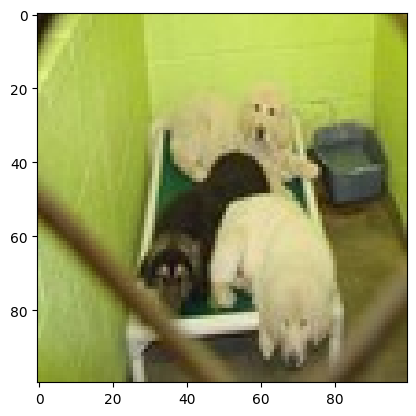

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
[[0.06458247]]
our models says, it is a Dog


In [ ]:
# install tensorflow in cmd prompt -  pip install tensorflow
# keras can also be installed separately  - pip install keras
import matplotlib.pyplot as plt
import numpy as np
import random as random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

import os
current_directory = os.getcwd()
print(f"Current Working Directory: {current_directory}")
from pathlib import Path

current_path = Path.cwd()
print(f"Current path: {current_path}")
"""import pandas as pd

filename = 'input.csv'
num_rows_to_read = 5

# Option A: Read only the first N rows from the start
df = pd.read_csv(filename, nrows=5)
print(df)

# Option B: Load the DataFrame and then use .head()
# (Use with caution on very large files, might load whole file first depending on implementation)
df_full = pd.read_csv(filename)
print(df_full.head(num_rows_to_read))

filename1 = 'labels.csv' # labels are the output columns
num_rows_to_read = 5

# Option A: Read only the first N rows from the start
df1 = pd.read_csv(filename1, nrows=5)
print(df)

# Option B: Load the DataFrame and then use .head()
# (Use with caution on very large files, might load whole file first depending on implementation)
df_full1 = pd.read_csv(filename1)
print(df_full1.head(num_rows_to_read))"""

x_train=np.loadtxt('input.csv',delimiter=',')
y_train=np.loadtxt('labels.csv',delimiter=',')
x_test=np.loadtxt('input_test.csv',delimiter=',')
y_test=np.loadtxt('labels_test.csv',delimiter=',')

x_train=x_train.reshape(len(x_train),100,100,3)
y_train=y_train.reshape(len(y_train),1)

x_test=x_test.reshape(len(x_test),100,100,3) # reshaped to size 100 * 100 *3
y_test=y_test.reshape(len(y_test),1)

x_train=x_train/255 # values less than 1
x_test=x_test/255

print("shape of X-train:", x_train.shape)
print("shape of y_train:",y_train.shape)
print("shape of X-test:", x_test.shape)
print("shape of y_test:",y_test.shape)

x_train[1,:] # print single image data: values between 250 typical for RGB...go up and divide by 255
idx= random.randint(0,len(x_train)) #len(x_train) is size of dataset
plt.imshow(x_train[idx,:]) # print single image

#Model: Layers are stacked on top of each other---CNN and Max Pulling Layers stacked on top of each other ina a sequence
model = Sequential([
    Conv2D(32, (3,3),activation='relu',input_shape=(100,100,3)),
    MaxPooling2D((2,2)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])

model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu',input_shape=(100,100,3)))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

#opt = Keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, batch_size=64)
model.evaluate(x_test, y_test)
# making predictions
idx2= random.randint(0,len(y_test))
plt.imshow(x_test[idx2,:])
plt.show()
y_pred = model.predict(x_test[idx2,:].reshape(1,100,100,3))
print(y_pred)
y_pred= y_pred>0.5
if(y_pred==1):
    pred="Cat"
else:
    pred="Dog"
print("our model says, it is a", pred)

